### Import packages

In [323]:
%load_ext autoreload
%autoreload 2

#Import general libs you'll need
import os
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np

# Import functions from main
from main import ATL_AGG_CONFIG

# Import functions from the utils
from utils import readers, analysis, processing
from utils import plotter
from utils.create_las_swath import create_als_swath, transform_als_swath
from utils.datum_transforms import convert_3d_nad83_to_wgs84
from utils.datum_transforms import get_geoid_height



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Identify files



In [324]:
atl03_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/austin'
atl03_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/footprint_exp/austin_data'
atl03_name = 'ATL03_20250616013703_00052802_007_01.h5'
atl03_name = 'ATL03_20181215070448_11860106_007_01.h5'
atl03_file = os.path.join(atl03_dir, atl03_name)

# Define ATL08 File /home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/austin
atl08_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/austin'
atl08_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/footprint_exp/austin_data'
atl08_name = 'ATL08_20250616013703_00052802_007_01.h5'
atl08_name = 'ATL08_20181215070448_11860106_007_01.h5'
atl08_file = os.path.join(atl08_dir, atl08_name)

# Define the ground track of interest
gt = 'gt2l'

# Identify ATX AOI
extent_file = '/home/ejg2736/dev/icesat2_topobathy/data/austin_laz_bigtex.gpkg'

# ALS Geoid File
als_geoid_file = '/home/ejg2736/dev/geoid/agisoft/us_noaa_g2018u0.tif'

### Get photon rate dataframe


In [325]:
# Get photon rate DF
df_ph = readers.read_photon_dataframe(atl03_file, gt, atl08_file)


In [326]:
df_ph['crosstrack'] = 0 

In [327]:
# Filter df_ph
extent_gdf = gpd.read_file(extent_file)
df_ph = processing.filter_df_by_extent(df_ph, extent_gdf.total_bounds)


### Plot output 

Check to make sure it plots correctly

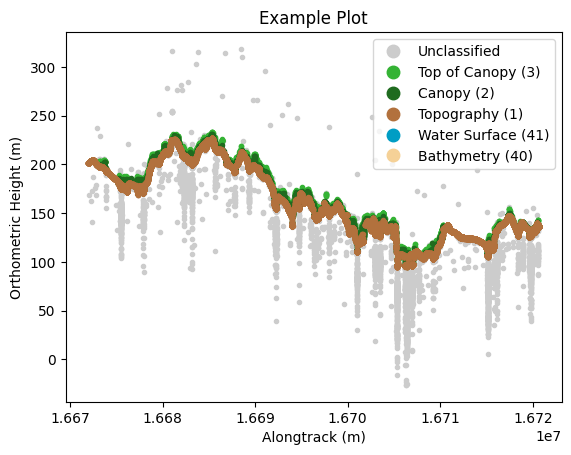

In [328]:
import matplotlib.pyplot as plt
plotter.plot_alongtrack(df_ph.alongtrack, df_ph.h_ph, df_ph.atl08_class,'Example Plot')

### Process ALS Swath

Load the ALS Swath and preprocess it 

In [329]:
atl03_basename = os.path.basename(atl03_name).split('.h5')[0]
print(atl03_basename)

ATL03_20181215070448_11860106_007_01


In [330]:
# Load swath if available
als_outdir = '/home/ejg2736/dev/icesat2_topobathy/als_swaths'
file_out_name = f"{os.path.basename(atl03_name).split('.h5')[0]}_{gt}"
als_outfile = os.path.join(als_outdir, f'als_{file_out_name}.pqt')                
if os.path.exists(als_outfile):
    als_swath = pd.read_parquet(als_outfile)
else:
    als_swath = create_als_swath(extent_gdf, df_ph)
    als_swath = transform_als_swath(als_swath, 
        'EPSG:32614', 
        source_geoid_file=als_geoid_file,
        target_geoid_file=None, 
        input_units='feet', 
        source_datum='nad83'
    )
    als_swath.to_parquet(als_outfile)

/home/ejg2736/miniconda3/envs/spyder_pr/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


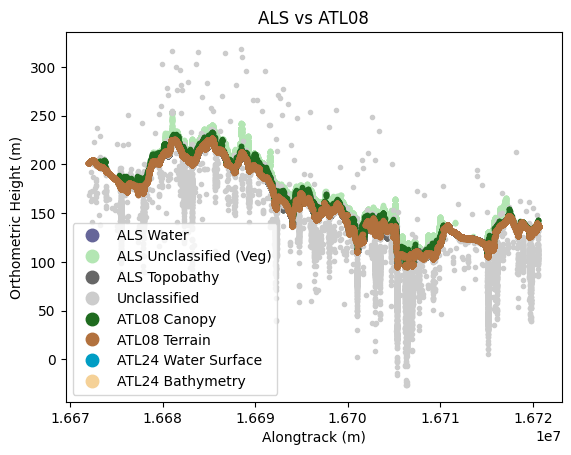

In [331]:
from utils.plotter import plot_alongtrack_atl_als3
plot_alongtrack_atl_als3(df_ph, als_swath,'ALS vs ATL08')

### Perform Geolocation Offset

Fine tune the fit between the ICESat-2 and the ALS swath.

In [332]:
%load_ext autoreload
%autoreload 2

# Call geolocation offset script
from utils.geolocation import create_interpolator


df_ph['crosstrack'] = 0


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [333]:
als_surface_interpolator = create_interpolator(als_swath, grid_resolution=1)

In [334]:
from utils.geolocation import calculate_mae_cost
from scipy.optimize import minimize, brute, fmin


search_grid = (slice(-10, 10, 0.5), slice(-10, 10, 0.5))

result = brute(
    calculate_mae_cost, 
    ranges=search_grid, 
    args=(df_ph.alongtrack[df_ph.atl08_class == 1], 
    df_ph.crosstrack[df_ph.atl08_class == 1], 
    df_ph.h_ph[df_ph.atl08_class == 1], als_surface_interpolator),
    finish=fmin, 
    full_output=True 
)

optimal_shift_at, optimal_shift_xt = result[0]
best_mae = result[1]

print(f"AT shift: {optimal_shift_at:.2f} m")
print(f"XT shift: {optimal_shift_xt:.2f} m")
print(f"Best MAE: {result[1]:.2f} m")

AT shift: 0.02 m
XT shift: 2.17 m
Best MAE: 0.72 m


In [ ]:
from utils.geolocation import calculate_z_shift


optimal_shift_z = calculate_z_shift(df_ph.alongtrack[df_ph.atl08_class == 1], 
                                    df_ph.crosstrack[df_ph.atl08_class == 1],  
                                    df_ph.h_ph[df_ph.atl08_class == 1], 
                                    optimal_shift_at, 
                                    optimal_shift_xt , 
                                    als_surface_interpolator)



In [336]:
# apply crosstrack and alongtrack shift to the ALS swath to make the math easier
als_swath['alongtrack'] = als_swath['alongtrack'] - optimal_shift_at
als_swath['crosstrack'] = als_swath['crosstrack'] - optimal_shift_xt


In [337]:
import geopandas as gpd

# Define roughly the bounding box for Austin (Min Long, Min Lat, Max Long, Max Lat)
# austin_bbox = (-98.1, 30.1, -97.5, 30.5)

# Load ONLY the buildings within that bounding box from the local file
# Note: Geopandas can read directly from the zipped file!
# file_path = "/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/footprint/Texas.geojson"
# austin_buildings = gpd.read_file(file_path, bbox=austin_bbox)

# print(f"Loaded {len(austin_buildings)} buildings in the Austin area.")
austin_building_file = "/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/footprint/austin_bldgs.gpkg"
#austin_buildings.to_file( austin_building_file,driver='GPKG')

In [338]:
austin_buildings = gpd.read_file(austin_building_file)
len(austin_buildings)

405561

In [340]:
%load_ext autoreload
%autoreload 2

from utils.create_las_swath import prepare_icesat2_track
from utils.building_processing import find_intersected_buildings, convert_buildings_to_atxt, remove_complex_intersections

# 1. Prepare data once
gdf_buildings_utm = austin_buildings.to_crs('EPSG:32614')

is2_line_utm, line_x, line_y, line_at_dist = prepare_icesat2_track(
    df_ph, utm_epsg='EPSG:32614', resolution_m=10.0
)

# 2. Pipeline the data through the modular functions
candidates_utm = find_intersected_buildings(
    is2_line_utm, gdf_buildings_utm, buffer_meters=5.0, building_filter_size=300.0
)

# 3. Remove buildings that have complicated building shapes
clean_candidates = remove_complex_intersections(candidates_utm, is2_line_utm)

buildings_atxt = convert_buildings_to_atxt_fast(
    clean_candidates, is2_line_utm, line_x, line_y, line_at_dist
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Dropped 5 buildings due to complex geometry intersections.


In [342]:
data = {
    'name': [f'{atl03_basename}_{gt}'],
    'geometry': [is2_line_utm]
}

# 3. Initialize the GeoDataFrame with a CRS
gdf = gpd.GeoDataFrame(data, crs="EPSG:32614")

# 4. Write to GeoPackage
# Use 'engine="pyogrio"' for high-performance writing
gdf.to_file(f"test_path2.gpkg", layer='layer',driver="GPKG", engine="pyogrio")

In [343]:
candidates_utm.to_file('candidate_buildings.gpkg', driver='GPKG',index=True)

In [344]:
%load_ext autoreload
%autoreload 2

from utils.building_processing import filter_grazing_hits

hit_buildings = filter_grazing_hits(buildings_atxt)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Filtered out 33 grazing hits.


In [345]:
# target_building_id = 273324
# target_building_id = 17636
target_building_id = 159174
# target_building_id = 2479
target_building_id = 198116
target_building = hit_buildings.loc[target_building_id].geometry.buffer(20) 
target_building_atxt = buildings_atxt.loc[target_building_id].geometry.buffer(20) 

In [346]:
from utils.building_processing import clip_als_to_buffered_building
target_als = clip_als_to_buffered_building(als_swath, target_building, buffer_m=1.0)
target_als = target_als[np.abs(target_als.crosstrack) < 6] 




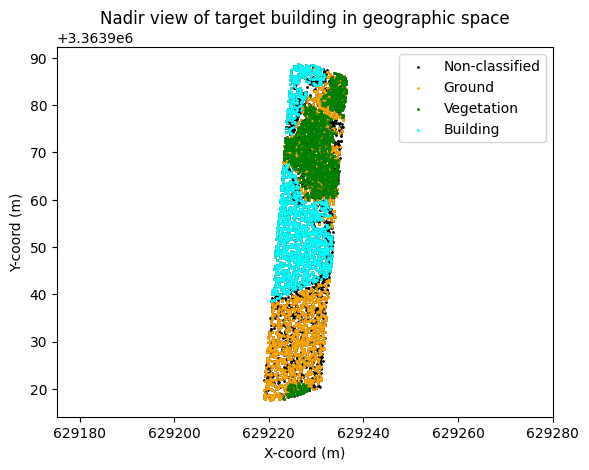

In [347]:
cmap = plt.get_cmap('viridis')
# colors = cmap(target_als.h_norm[target_als.classification==6]) 
plt.scatter(target_als.x, target_als.y,c='k',label='Non-classified',s=1)
plt.scatter(target_als.x[target_als.classification==2], target_als.y[target_als.classification==2],c='orange',s=1,label='Ground')
plt.scatter(target_als.x[target_als.classification==3], target_als.y[target_als.classification==3],c='g',s=1,label='Vegetation')
plt.scatter(target_als.x[target_als.classification==6], target_als.y[target_als.classification==6],c='cyan',s=1,label='Building')
plt.legend()
plt.title('Nadir view of target building in geographic space')
plt.xlabel('X-coord (m)')
plt.ylabel('Y-coord (m)')
plt.axis('equal')
plt.show()

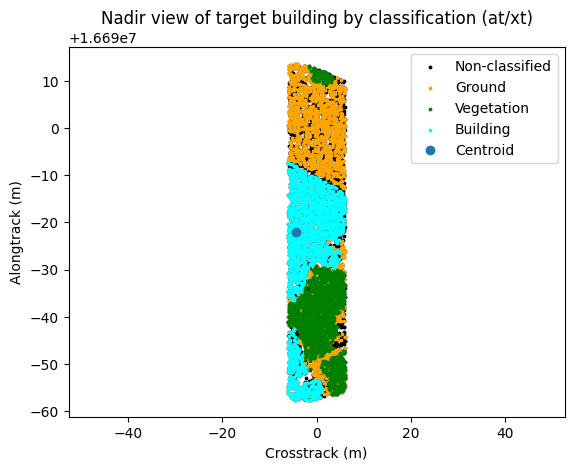

In [348]:
cmap = plt.get_cmap('viridis')
# colors = cmap(target_als.h_norm[target_als.classification==6]) 
plt.scatter(target_als.crosstrack, target_als.alongtrack,c='k',label='Non-classified',s=3)
plt.scatter(target_als.crosstrack[target_als.classification==2], target_als.alongtrack[target_als.classification==2],c='orange',s=3,label='Ground')
plt.scatter(target_als.crosstrack[target_als.classification==3], target_als.alongtrack[target_als.classification==3],c='g',s=3,label='Vegetation')
plt.scatter(target_als.crosstrack[target_als.classification==6], target_als.alongtrack[target_als.classification==6],c='cyan',s=3,label='Building')
plt.plot(target_building_atxt.centroid.y, target_building_atxt.centroid.x,'o',label='Centroid')

plt.legend()
plt.title('Nadir view of target building by classification (at/xt)')
plt.xlabel('Crosstrack (m)')
plt.ylabel('Alongtrack (m)')
plt.axis('equal')
plt.show()

In [349]:
%load_ext autoreload
%autoreload 2
from utils.building_processing import extract_building_edges_2d
edge = extract_building_edges_2d(target_als, target_building_atxt)
edge


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Rejecting Entry Edge: Failed Inlier Ratio (Likely an Extent Corner)
Rejecting Exit Edge: Failed Flatness: Roof edge is too rough or sloped (IQR: 0.51m)


{'entry': {'slope': np.float64(1.3859464098998429),
  'intercept': np.float64(16689971.617004808),
  'valid': False,
  'reason': 'Failed Inlier Ratio (Likely an Extent Corner)',
  'roof_median_h': nan,
  'roof_iqr': nan},
 'exit': {'slope': np.float64(-0.5376132040581493),
  'intercept': np.float64(16689989.714214647),
  'valid': False,
  'reason': 'Failed Flatness: Roof edge is too rough or sloped (IQR: 0.51m)',
  'roof_median_h': np.float64(10.243566000000001),
  'roof_iqr': np.float64(0.5093970000000141)}}

In [350]:
from utils.building_processing import create_line
x_entry,y_entry = create_line(edge['entry']['slope'], edge['entry']['intercept'], x_start=-7, x_stop = 7)
x_exit,y_exit = create_line(edge['exit']['slope'], edge['exit']['intercept'], x_start=-7, x_stop = 7)

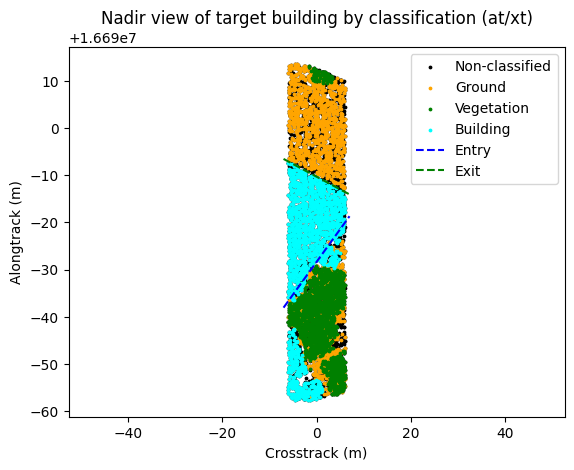

In [351]:
cmap = plt.get_cmap('viridis')
# colors = cmap(target_als.h_norm[target_als.classification==6]) 
plt.scatter(target_als.crosstrack, target_als.alongtrack,c='k',label='Non-classified',s=3)
plt.scatter(target_als.crosstrack[target_als.classification==2], target_als.alongtrack[target_als.classification==2],c='orange',s=3,label='Ground')
plt.scatter(target_als.crosstrack[target_als.classification==3], target_als.alongtrack[target_als.classification==3],c='g',s=3,label='Vegetation')
plt.scatter(target_als.crosstrack[target_als.classification==6], target_als.alongtrack[target_als.classification==6],c='cyan',s=3,label='Building')
plt.plot(x_entry,y_entry,'b--',label = 'Entry')
plt.plot(x_exit,y_exit,'g--',label = 'Exit')
plt.legend()
plt.title('Nadir view of target building by classification (at/xt)')
plt.xlabel('Crosstrack (m)')
plt.ylabel('Alongtrack (m)')
plt.axis('equal')
plt.show()

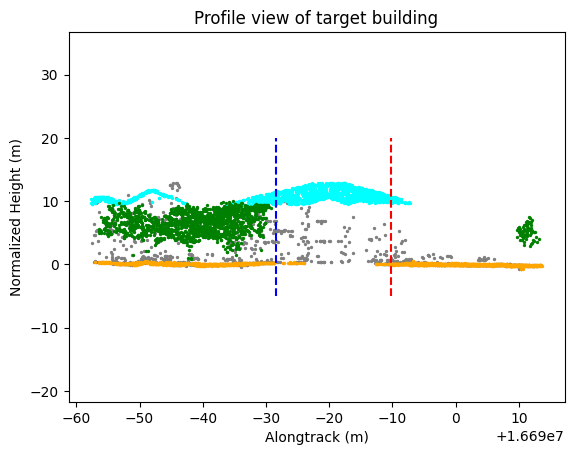

In [352]:
plt.scatter(target_als.alongtrack[target_als.classification == 1],target_als.h_norm[target_als.classification == 1],c='gray',s=2,label='Non-classified')
plt.scatter(target_als.alongtrack[target_als.classification == 6],target_als.h_norm[target_als.classification == 6],c='cyan',s=2,label='Building')
plt.scatter(target_als.alongtrack[target_als.classification == 2],target_als.h_norm[target_als.classification == 2],c='orange',s=2,label='Ground')
plt.scatter(target_als.alongtrack[target_als.classification == 3],target_als.h_norm[target_als.classification == 3],c='green',s=2,label='Vegetation')

plt.plot([edge['entry']['intercept'],edge['entry']['intercept']],[-5,20],'b--',label = 'Entry')
plt.plot([edge['exit']['intercept'],edge['exit']['intercept']],[-5,20],'r--',label = 'Exit')
plt.title('Profile view of target building')
plt.xlabel('Alongtrack (m)')
plt.ylabel('Normalized Height (m)')
plt.axis('equal')
plt.show()

In [353]:
target_ph = df_ph[(edge['exit']['intercept'] + 50) > df_ph.alongtrack] 
target_ph = target_ph[(edge['exit']['intercept'] - 50) < df_ph.alongtrack] 
print(target_ph.columns)
# target_ph = target_ph[target_ph.h_norm < 130]
# target_ph = target_ph[target_ph.h_norm > -10]
len(target_ph)

Index(['latitude', 'longitude', 'h_ph', 'quality_ph', 'delta_time',
       'alongtrack', 'solar_elevation', 'atl08_class', 'h_norm', 'crosstrack'],
      dtype='object')


/tmp/ipykernel_2101509/1728685980.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  target_ph = target_ph[(edge['exit']['intercept'] - 50) < df_ph.alongtrack]


92

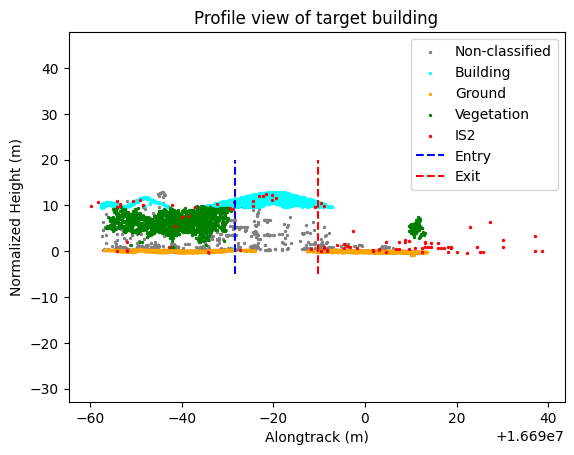

In [354]:
plt.scatter(target_als.alongtrack[target_als.classification == 1],target_als.h_norm[target_als.classification == 1],c='gray',s=2,label='Non-classified')
plt.scatter(target_als.alongtrack[target_als.classification == 6],target_als.h_norm[target_als.classification == 6],c='cyan',s=2,label='Building')
plt.scatter(target_als.alongtrack[target_als.classification == 2],target_als.h_norm[target_als.classification == 2],c='orange',s=2,label='Ground')
plt.scatter(target_als.alongtrack[target_als.classification == 3],target_als.h_norm[target_als.classification == 3],c='green',s=2,label='Vegetation')
plt.scatter(target_ph.alongtrack,target_ph.h_norm,c='red',s=2,label='IS2')


plt.plot([edge['entry']['intercept'],edge['entry']['intercept']],[-5,20],'b--',label = 'Entry')
plt.plot([edge['exit']['intercept'],edge['exit']['intercept']],[-5,20],'r--',label = 'Exit')
plt.title('Profile view of target building')
plt.legend()
plt.xlabel('Alongtrack (m)')
plt.ylabel('Normalized Height (m)')
plt.axis('equal')
plt.show()

In [355]:
%load_ext autoreload
%autoreload 2

from utils.building_processing import calculate_orthogonal_distance, classify_photons
target_ph['crosstrack'] = 0
target_ph = calculate_orthogonal_distance(target_ph, edge['entry'], 'entry', threshold_m=10.0)

target_ph = classify_photons(target_ph, edge['entry']['roof_median_h'], z_tolerance=1.0)

target_ph

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,latitude,longitude,h_ph,quality_ph,delta_time,alongtrack,solar_elevation,atl08_class,h_norm,crosstrack,dist_to_wall,target_class
5474261,30.400866,-97.654752,199.027069,0,3.009315e+07,1.668996e+07,-77.368774,2,0.844620,0,-8.459713,ground
5474262,30.400860,-97.654752,208.257141,0,3.009315e+07,1.668996e+07,-77.368774,3,10.102905,0,-8.044077,noise
5474263,30.400854,-97.654753,203.711121,0,3.009315e+07,1.668996e+07,-77.368774,2,5.584915,0,-7.631704,noise
5474264,30.400841,-97.654755,205.571533,0,3.009315e+07,1.668996e+07,-77.368774,2,7.473068,0,-6.804339,noise
5474265,30.400828,-97.654756,205.826920,0,3.009315e+07,1.668996e+07,-77.368774,2,7.755920,0,-5.977302,noise
5474266,30.400816,-97.654757,207.712585,0,3.009315e+07,1.668996e+07,-77.368774,3,9.668716,0,-5.149851,noise
5474267,30.400790,-97.654760,197.960663,0,3.009315e+07,1.668997e+07,-77.368774,1,-0.056473,0,-3.497933,ground
5474268,30.400771,-97.654762,208.204651,0,3.009315e+07,1.668997e+07,-77.368866,3,10.213654,0,-2.254753,noise
5474269,30.400746,-97.654765,207.415710,0,3.009315e+07,1.668997e+07,-77.368866,3,9.450256,0,-0.600247,noise
5474270,30.400739,-97.654766,208.599625,0,3.009315e+07,1.668997e+07,-77.368866,3,10.659119,0,-0.186273,noise


In [356]:
from utils.building_processing import compute_esf

esf_df = compute_esf(target_ph, min_dist=-10.0, max_dist=10.0, bin_size=0.5)

In [357]:
from utils.building_processing import clip_als_to_buffered_building
from utils.building_processing import extract_building_edges_2d


# target_building = hit_buildings.loc[target_building_id].geometry.buffer(20) 
for target_building_id in hit_buildings.index:
    print(target_building_id)
    target_building = hit_buildings.loc[target_building_id].geometry.buffer(20) 
    target_atxt = buildings_atxt.loc[target_building_id].geometry.buffer(20) 
    target_als = clip_als_to_buffered_building(als_swath, target_building, buffer_m=1.0)
    target_als = target_als[np.abs(target_als.crosstrack) < 7] 

    edge = extract_building_edges_2d(target_als, target_atxt)
    for direction in ['entry','exit']:
        if edge[direction]['valid']:
            

            out_name = f'{atl03_basename}_{gt}_{target_building_id}_{direction}'
            print(out_name)

            intercept = edge[direction]['intercept']
            target_ph = df_ph[df_ph.alongtrack.between(intercept - 50, intercept + 50)]

            from utils.building_processing import calculate_orthogonal_distance, classify_photons
            target_ph = calculate_orthogonal_distance(target_ph, edge[direction], direction, threshold_m=10.0)

            target_ph = classify_photons(target_ph, edge[direction]['roof_median_h'], z_tolerance=1.0)

            target_ph.to_parquet(f'outputs/{out_name}_out.pqt')


2479
Rejecting Entry Edge: Failed Inlier Ratio (Likely an Extent Corner)
Rejecting Exit Edge: Failed Flatness: Roof edge is too rough or sloped (IQR: 1.81m)
17636
Rejecting Exit Edge: Failed Clearance: Tall vegetation or building in approach path
ATL03_20181215070448_11860106_007_01_gt2l_17636_entry
63548
Rejecting Entry Edge: Failed Flatness: Roof edge is too rough or sloped (IQR: 0.54m)
Rejecting Exit Edge: Failed Flatness: Roof edge is too rough or sloped (IQR: 0.81m)
79229
Rejecting Entry Edge: Failed Flatness: Roof edge is too rough or sloped (IQR: 1.51m)
Rejecting Exit Edge: Failed Inlier Ratio (Likely an Extent Corner)
79245
Rejecting Entry Edge: Failed Inlier Ratio (Likely an Extent Corner)
Rejecting Exit Edge: Failed Residual Curve (Likely a Slice Corner)
81083
Rejecting Entry Edge: Failed Residual Curve (Likely a Slice Corner)
ATL03_20181215070448_11860106_007_01_gt2l_81083_exit
81339
Rejecting Entry Edge: Failed Flatness: Roof edge is too rough or sloped (IQR: 3.02m)
Rejecti

In [358]:
target_building_id

377477

In [359]:
edge[direction]

{'slope': np.float64(-0.2821418521242108),
 'intercept': np.float64(16679690.826556822),
 'valid': False,
 'reason': 'Failed Clearance: Tall vegetation or building in approach path',
 'roof_median_h': np.float64(3.299459999999982),
 'roof_iqr': np.float64(0.10287000000001711)}

In [360]:
out_name = f'{atl03_basename}_{gt}_{target_building_id}_{direction}'


In [367]:
f_dir = '/home/ejg2736/dev/icesat2_topobathy/outputs/test_valid_hits_pqt3/'

f_list = os.listdir(f_dir)

df_list = []
for f in f_list:
    df = pd.read_parquet(os.path.join(f_dir,f))
    df['file_name'] = f
    if (len(df[df.target_class == 'ground']) > 3) &\
        (len(df[df.target_class == 'roof']) > 3) &\
        (np.max(df.dist_to_wall[df.target_class == 'ground']) < 9)  &\
        (np.min(df.dist_to_wall[df.target_class == 'roof']) > -9 ):

        df_list.append(df)
    else:
        print(f'Rejected {f}')

valid_df = pd.concat(df_list,ignore_index=True)




Rejected ATL03_20181215070448_11860106_007_01_gt2l_17636_entry_out.pqt
Rejected ATL03_20181215070448_11860106_007_01_gt2l_159174_entry_out.pqt
Rejected ATL03_20181215070448_11860106_007_01_gt2l_377477_entry_out.pqt


In [362]:
valid_df

,latitude,longitude,h_ph,quality_ph,delta_time,alongtrack,solar_elevation,atl08_class,h_norm,crosstrack,dist_to_wall,target_class,file_name
0,30.493269,-97.644384,211.207504,0,3.009314e+07,1.667967e+07,-77.316940,3,7.304138,0,9.581695,roof,ATL03_20181215070448_11860106_007_01_gt2l_8108...
1,30.493263,-97.644385,211.165405,0,3.009314e+07,1.667967e+07,-77.316940,3,7.252594,0,8.908763,roof,ATL03_20181215070448_11860106_007_01_gt2l_8108...
2,30.493256,-97.644386,211.311279,0,3.009314e+07,1.667967e+07,-77.316940,3,7.389786,0,8.235723,roof,ATL03_20181215070448_11860106_007_01_gt2l_8108...
3,30.493250,-97.644386,210.941483,0,3.009314e+07,1.667967e+07,-77.316940,3,7.012070,0,7.562971,roof,ATL03_20181215070448_11860106_007_01_gt2l_8108...
4,30.493243,-97.644387,211.185532,0,3.009314e+07,1.667967e+07,-77.316940,3,7.248901,0,6.889909,roof,ATL03_20181215070448_11860106_007_01_gt2l_8108...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,30.312235,-97.664642,145.897339,0,3.009315e+07,1.669983e+07,-77.418007,2,1.213516,0,5.940886,noise,ATL03_20181215070448_11860106_007_01_gt2l_3489...
208,30.312216,-97.664644,147.533966,0,3.009315e+07,1.669983e+07,-77.418007,3,2.686905,0,7.898057,noise,ATL03_20181215070448_11860106_007_01_gt2l_3489...
209,30.312209,-97.664645,148.769867,0,3.009315e+07,1.669983e+07,-77.418007,3,3.760315,0,8.550685,roof,ATL03_20181215070448_11860106_007_01_gt2l_3489...
210,30.312197,-97.664647,148.420624,0,3.009315e+07,1.669983e+07,-77.418106,3,3.249985,0,9.854825,roof,ATL03_20181215070448_11860106_007_01_gt2l_3489...


In [368]:
from utils.building_processing import compute_esf


esf_df = compute_esf(valid_df, min_dist=-10.0, max_dist=10.0, bin_size=1.5)

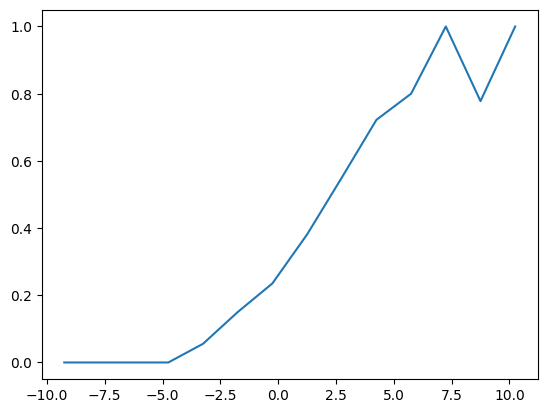

In [369]:
plt.plot(esf_df.distance_to_wall,esf_df.esf_ratio)

In [365]:
unique_files = np.unique(valid_df.file_name)

test_df = valid_df[valid_df.file_name == unique_files[12]]

plt.plot(test_df.dist_to_wall[test_df.target_class=='noise'],test_df.h_norm[test_df.target_class=='noise'],'.k')
plt.plot(test_df.dist_to_wall[test_df.target_class=='ground'],test_df.h_norm[test_df.target_class=='ground'],'.r')
plt.plot(test_df.dist_to_wall[test_df.target_class=='roof'],test_df.h_norm[test_df.target_class=='roof'],'.g')

IndexError: index 12 is out of bounds for axis 0 with size 5

In [ ]:
len(unique_files)

13

In [ ]:
unique_files[13]

'ATL03_20181215070448_11860106_007_01_gt2l_81083_exit_out.pqt'

In [ ]:
unique_files[0]

In [ ]:
unique_files[11]